In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
train_data = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

In [3]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
test_data = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [5]:
test_data

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [6]:
print(train_data.shape)
print(test_data.shape)
train_data.info()
train_data.isnull().sum()

(891, 12)
(418, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())

In [8]:
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

train_data['Embarked'] = train_data['Embarked'].fillna(
    train_data['Embarked'].mode()[0]
)

train_data['Age'] = train_data['Age'].fillna(
    train_data['Age'].median()
)

test_data['Age'] = test_data['Age'].fillna(
    test_data['Age'].median()
)

In [9]:
print(train_data.isnull().sum())
print(test_data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64
PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


In [10]:
train_data.drop(['Name', 'Ticket'], axis=1, inplace=True)
test_data.drop(['Name', 'Ticket'], axis=1, inplace=True)

In [11]:
le_sex = LabelEncoder() 
train_data['Sex'] = le_sex.fit_transform( train_data['Sex'] ) 
test_data['Sex'] = le_sex.transform( test_data['Sex'] )

In [12]:
le_embarked = LabelEncoder() 
train_data['Embarked'] = le_embarked.fit_transform( train_data['Embarked'] ) 
test_data['Embarked'] = le_embarked.transform( test_data['Embarked'] )

In [13]:
X = train_data.drop('Survived', axis=1) 
X = X.drop('PassengerId', axis=1) 
y = train_data['Survived']

In [14]:
X_train, X_valid, y_train, y_valid = train_test_split( X, y, test_size=0.2, random_state=42 )

In [15]:
print(X_train.dtypes)

Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked      int64
dtype: object


In [16]:
train_data.drop('Cabin', axis=1, inplace=True, errors='ignore') 
test_data.drop('Cabin', axis=1, inplace=True, errors='ignore')

In [17]:
print(X_train.dtypes)

Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked      int64
dtype: object


In [18]:
X = train_data.drop(['Survived', 'PassengerId'], axis=1) 
y = train_data['Survived']

In [19]:
print(X_train.dtypes)

Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked      int64
dtype: object


In [20]:
X_train, X_valid, y_train, y_valid = train_test_split( X, y, test_size=0.2, random_state=42 )

In [21]:
print(X_train.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [22]:
model = RandomForestClassifier( n_estimators=200, max_depth=5, random_state=42 )
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [23]:
pred = model.predict(X_valid) 
accuracy = accuracy_score( y_valid, pred ) 
print("Accuracy:", accuracy)

Accuracy: 0.8156424581005587


In [24]:
model.fit(X, y)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [25]:
X_test = test_data.drop( 'PassengerId', axis=1 )

In [26]:
predictions = model.predict(X_test)

In [27]:
submission = pd.DataFrame({ 'PassengerId': test_data['PassengerId'], 'Survived': predictions })
submission.to_csv( 'submission.csv', index=False ) 
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [28]:
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': predictions
})

submission.to_csv(
    '/kaggle/working/submission.csv',
    index=False
)

print("submission.csv created successfully!")

#Preview the file:

submission.head()

#Verify that the file exists:

import os

print(os.listdir('/kaggle/working'))

submission.csv created successfully!
['.virtual_documents', 'submission.csv']


In [29]:
submit_data = pd.read_csv("/kaggle/working/submission.csv")

In [30]:
submit_data

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [31]:
print(submit_data.isnull().sum())

PassengerId    0
Survived       0
dtype: int64


In [32]:
train_data.groupby('Sex')['Survived'].sum()

Sex
0    233
1    109
Name: Survived, dtype: int64

In [33]:
pd.crosstab(
    train_data['Sex'],
    train_data['Survived']
)

Survived,0,1
Sex,,
0,81,233
1,468,109


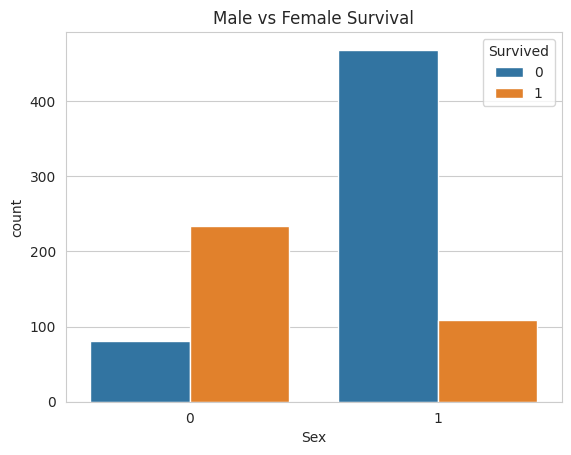

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='Sex',
    hue='Survived',
    data=train_data
)

plt.title("Male vs Female Survival")
plt.show()

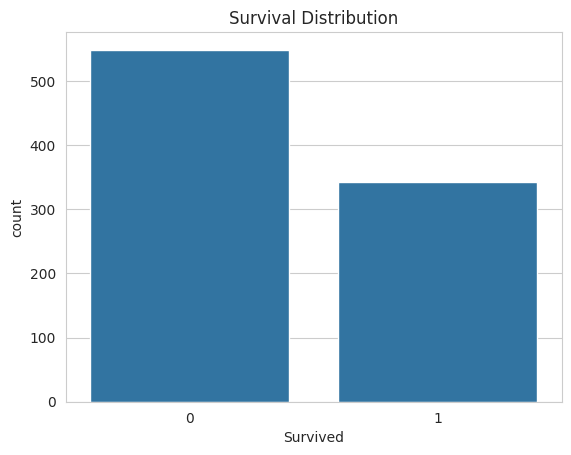

In [35]:
sns.countplot(x='Survived', data=train_data)

plt.title("Survival Distribution")
plt.show()

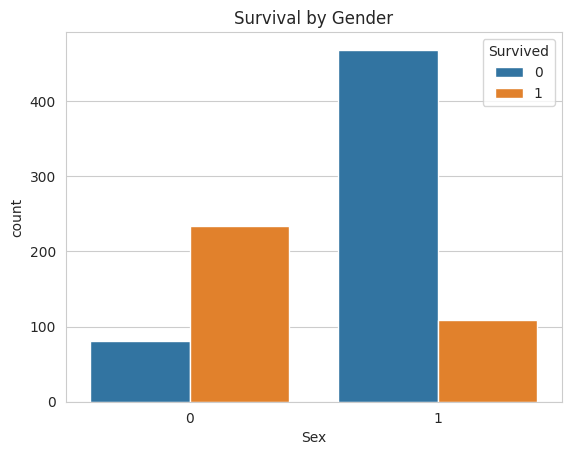

In [36]:
sns.countplot(
    x='Sex',
    hue='Survived',
    data=train_data
)

plt.title("Survival by Gender")
plt.show()

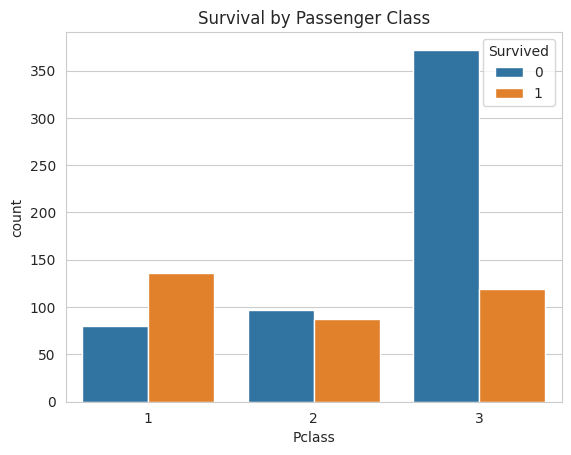

In [37]:
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=train_data
)

plt.title("Survival by Passenger Class")
plt.show()

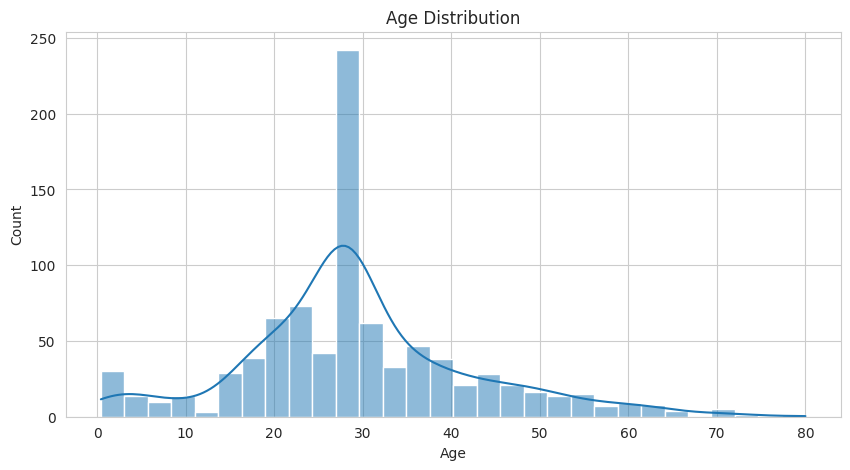

In [38]:
plt.figure(figsize=(10,5))

sns.histplot(
    train_data['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

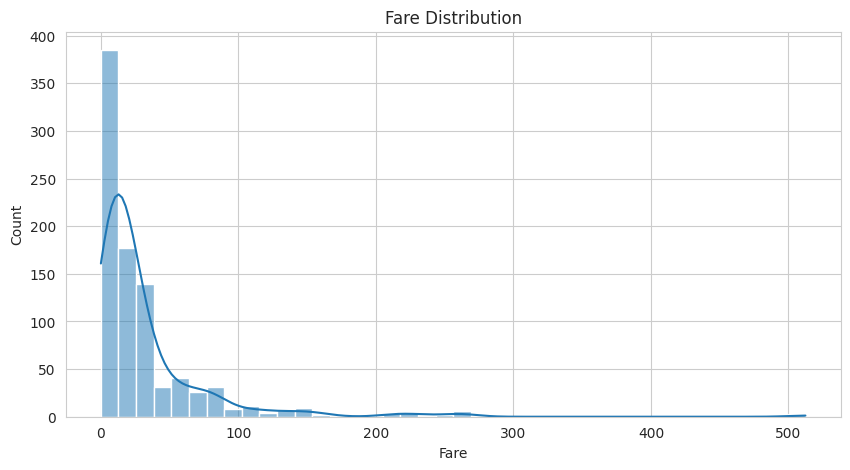

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(
    train_data['Fare'],
    bins=40,
    kde=True
)

plt.title("Fare Distribution")
plt.show()

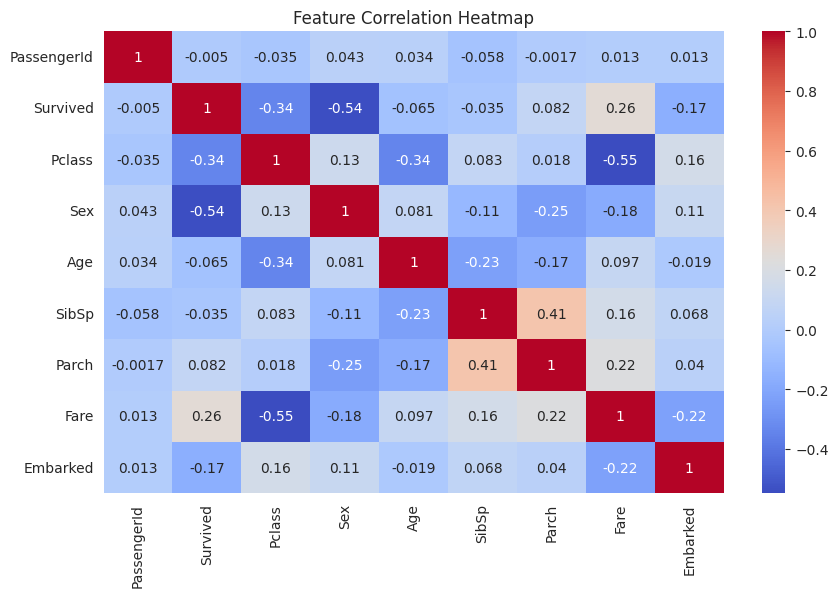

In [40]:
plt.figure(figsize=(10,6))

sns.heatmap(
    train_data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

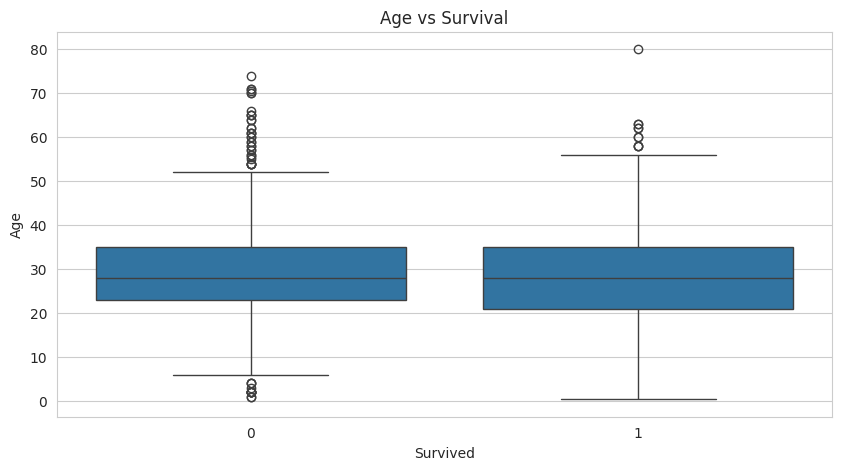

In [41]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Survived',
    y='Age',
    data=train_data
)

plt.title("Age vs Survival")
plt.show()

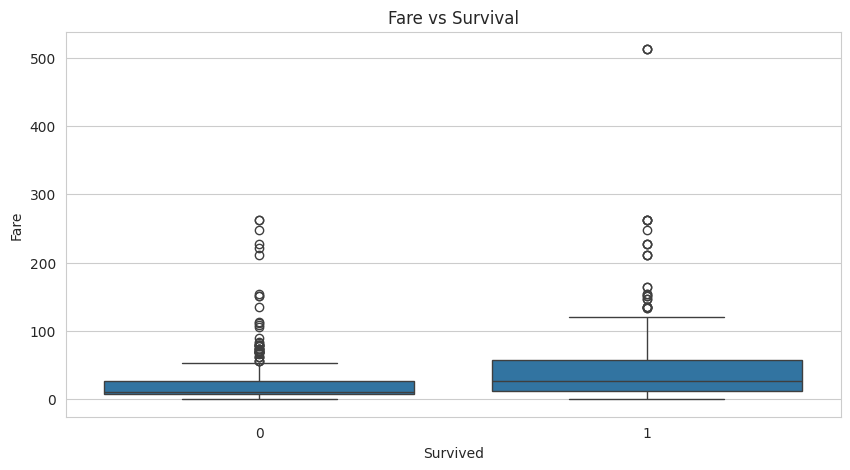

In [42]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Survived',
    y='Fare',
    data=train_data
)

plt.title("Fare vs Survival")
plt.show()

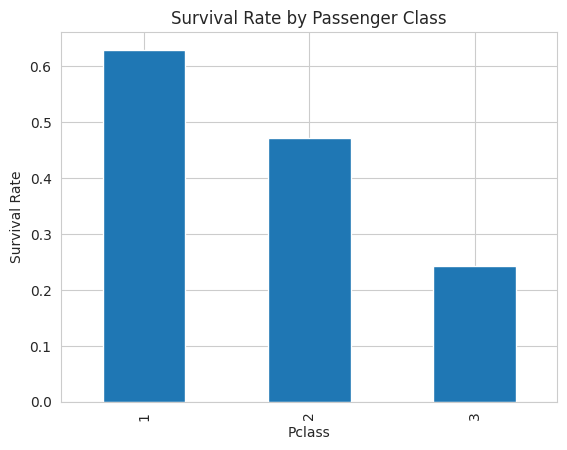

In [43]:
survival_rate = train_data.groupby('Pclass')['Survived'].mean()

survival_rate.plot(
    kind='bar'
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

In [44]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

    Feature  Importance
1       Sex    0.456431
5      Fare    0.170513
0    Pclass    0.151117
2       Age    0.105233
3     SibSp    0.050867
4     Parch    0.036311
6  Embarked    0.029528


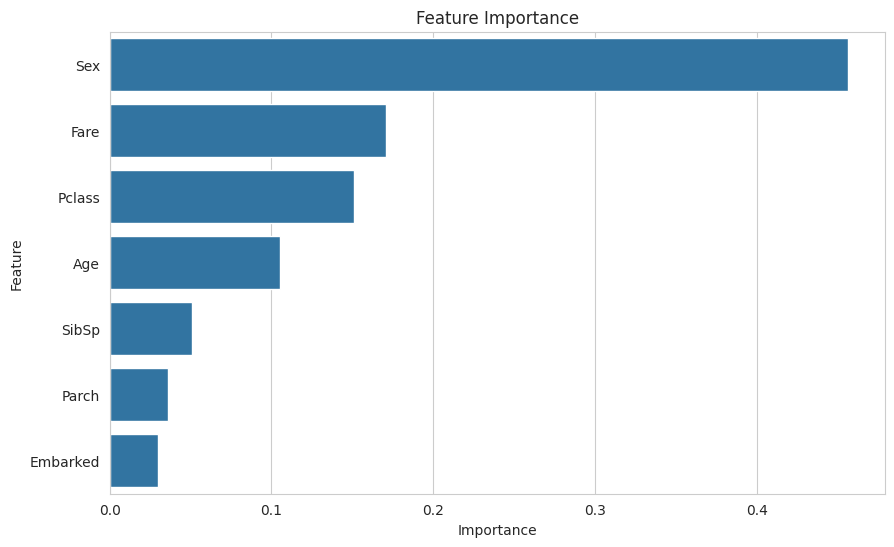

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [47]:
submit_data

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [48]:
submission.to_csv(
    '/kaggle/working/submission.csv',
    index=False
)

In [49]:
import os
print(os.listdir('/kaggle/working'))

['.virtual_documents', 'submission.csv']
